# 💧 Water Quality — Notebook 1: Preprocessing & EDA

This notebook covers:
- Data loading & inspection
- Exploratory Data Analysis (EDA)
- Missing value handling
- Outlier analysis
- Feature engineering
- Scaling & saving the processed dataset

The cleaned artefacts are saved to disk so **Notebook 2 (Modelling)** can load them directly.

## 1. Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
print('Libraries loaded ✅')

Libraries loaded ✅


## 2. Load Dataset

In [2]:
df = pd.read_csv('potability.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (8580, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.442537,180.859091,18223.027080,8.577250,405.320016,564.793485,14.768337,57.757554,2.191139,1
1,6.789821,197.300015,22527.681207,5.166942,399.981755,422.482029,15.916605,47.935105,4.512068,1
2,6.804796,223.995701,17196.054711,7.112622,374.309131,344.718314,15.457383,60.151346,4.847313,1
3,3.989032,216.076138,40175.206092,7.487423,309.800796,399.047181,11.186739,86.957464,4.409414,0
4,8.075495,195.804996,29483.601854,10.493841,298.737219,321.748339,9.751086,72.734423,3.682920,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8580 entries, 0 to 8579
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               8198 non-null   float64
 1   Hardness         8580 non-null   float64
 2   Solids           8580 non-null   float64
 3   Chloramines      8580 non-null   float64
 4   Sulfate          7968 non-null   float64
 5   Conductivity     8580 non-null   float64
 6   Organic_carbon   8580 non-null   float64
 7   Trihalomethanes  8461 non-null   float64
 8   Turbidity        8580 non-null   float64
 9   Potability       8580 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 670.4 KB


In [4]:
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
ph,8198.000000,7.073202,1.493194,0.000000,6.199818,7.080795,7.894197,14.000000
Hardness,8580.000000,196.302072,33.058931,47.432000,176.640064,197.102725,216.628561,323.124000
Solids,8580.000000,22033.735429,8720.038554,320.942611,15704.482093,20982.439792,27402.019999,56488.672413
Chloramines,8580.000000,7.142627,1.600986,0.352000,6.123298,7.150471,8.124403,13.127000
Sulfate,7968.000000,333.699122,39.279347,129.000000,313.344198,333.775777,355.087258,481.030643
Conductivity,8580.000000,426.121008,80.920116,181.483754,365.094144,421.464253,482.487877,753.342620
Organic_carbon,8580.000000,14.240330,3.326204,2.200000,12.022616,14.162809,16.520858,28.300000
Trihalomethanes,8461.000000,66.343424,15.988119,0.738000,56.044935,66.396293,77.157802,124.000000
Turbidity,8580.000000,3.964486,0.781744,1.450000,3.439022,3.955847,4.502020,6.739000
Potability,8580.000000,0.500000,0.500029,0.000000,0.000000,0.500000,1.000000,1.000000


## 3. Target Variable Analysis

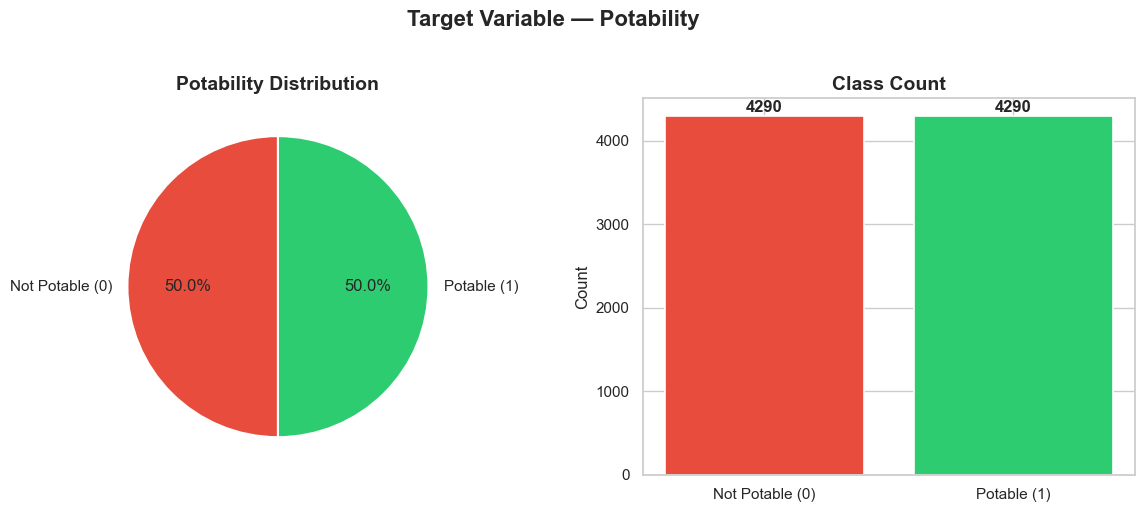

Class Balance Ratio  →  Not Potable : Potable = 1.00 : 1
⚠️  Mild class imbalance — will use stratified splits & balanced metrics.


In [5]:
target_counts = df['Potability'].value_counts()
labels = ['Not Potable (0)', 'Potable (1)']
colors = ['#e74c3c', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
axes[0].pie(target_counts, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Potability Distribution', fontsize=14, fontweight='bold')

# Count bar
bars = axes[1].bar(labels, target_counts.values, color=colors, edgecolor='white', linewidth=1.2)
for bar, count in zip(bars, target_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                 f'{count}', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[1].set_title('Class Count', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')

plt.suptitle('Target Variable — Potability', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

ratio = target_counts[0] / target_counts[1]
print(f'Class Balance Ratio  →  Not Potable : Potable = {ratio:.2f} : 1')
print('⚠️  Mild class imbalance — will use stratified splits & balanced metrics.')

## 4. Missing Value Analysis

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f'Total missing cells : {df.isnull().sum().sum()}')
display(missing_df.style.background_gradient(cmap='Reds'))

Total missing cells : 1113


,Missing Count,Missing %
Sulfate,612,7.130000
ph,382,4.450000
Trihalomethanes,119,1.390000


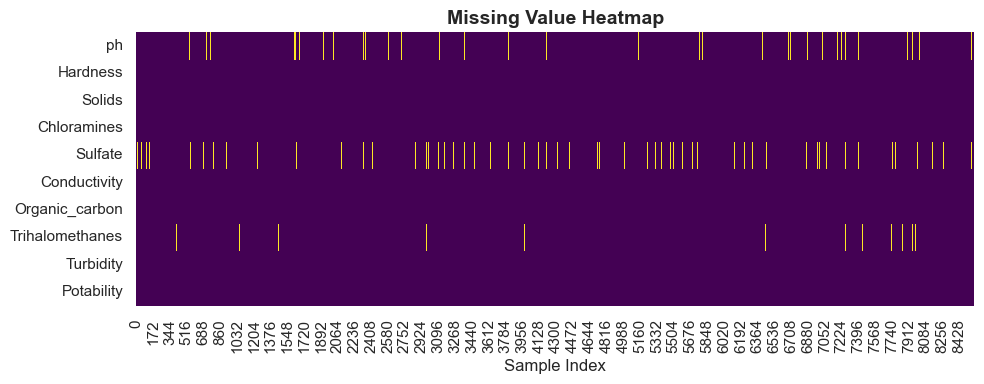

In [7]:
# Visualise missing data pattern
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df.isnull().T, cbar=False, cmap='viridis', ax=ax)
ax.set_title('Missing Value Heatmap', fontsize=14, fontweight='bold')
ax.set_xlabel('Sample Index')
plt.tight_layout()
plt.show()

In [8]:
# Fill missing values with per-column MEDIAN (robust to outliers)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

print(f'Missing after imputation : {df.isnull().sum().sum()} ✅')

Missing after imputation : 0 ✅


## 5. Duplicate Check

In [9]:
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes}')
if dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f'Removed {dupes} duplicates. New shape: {df.shape}')
else:
    print('No duplicates found ✅')

Duplicate rows: 0
No duplicates found ✅


## 6. Univariate Analysis

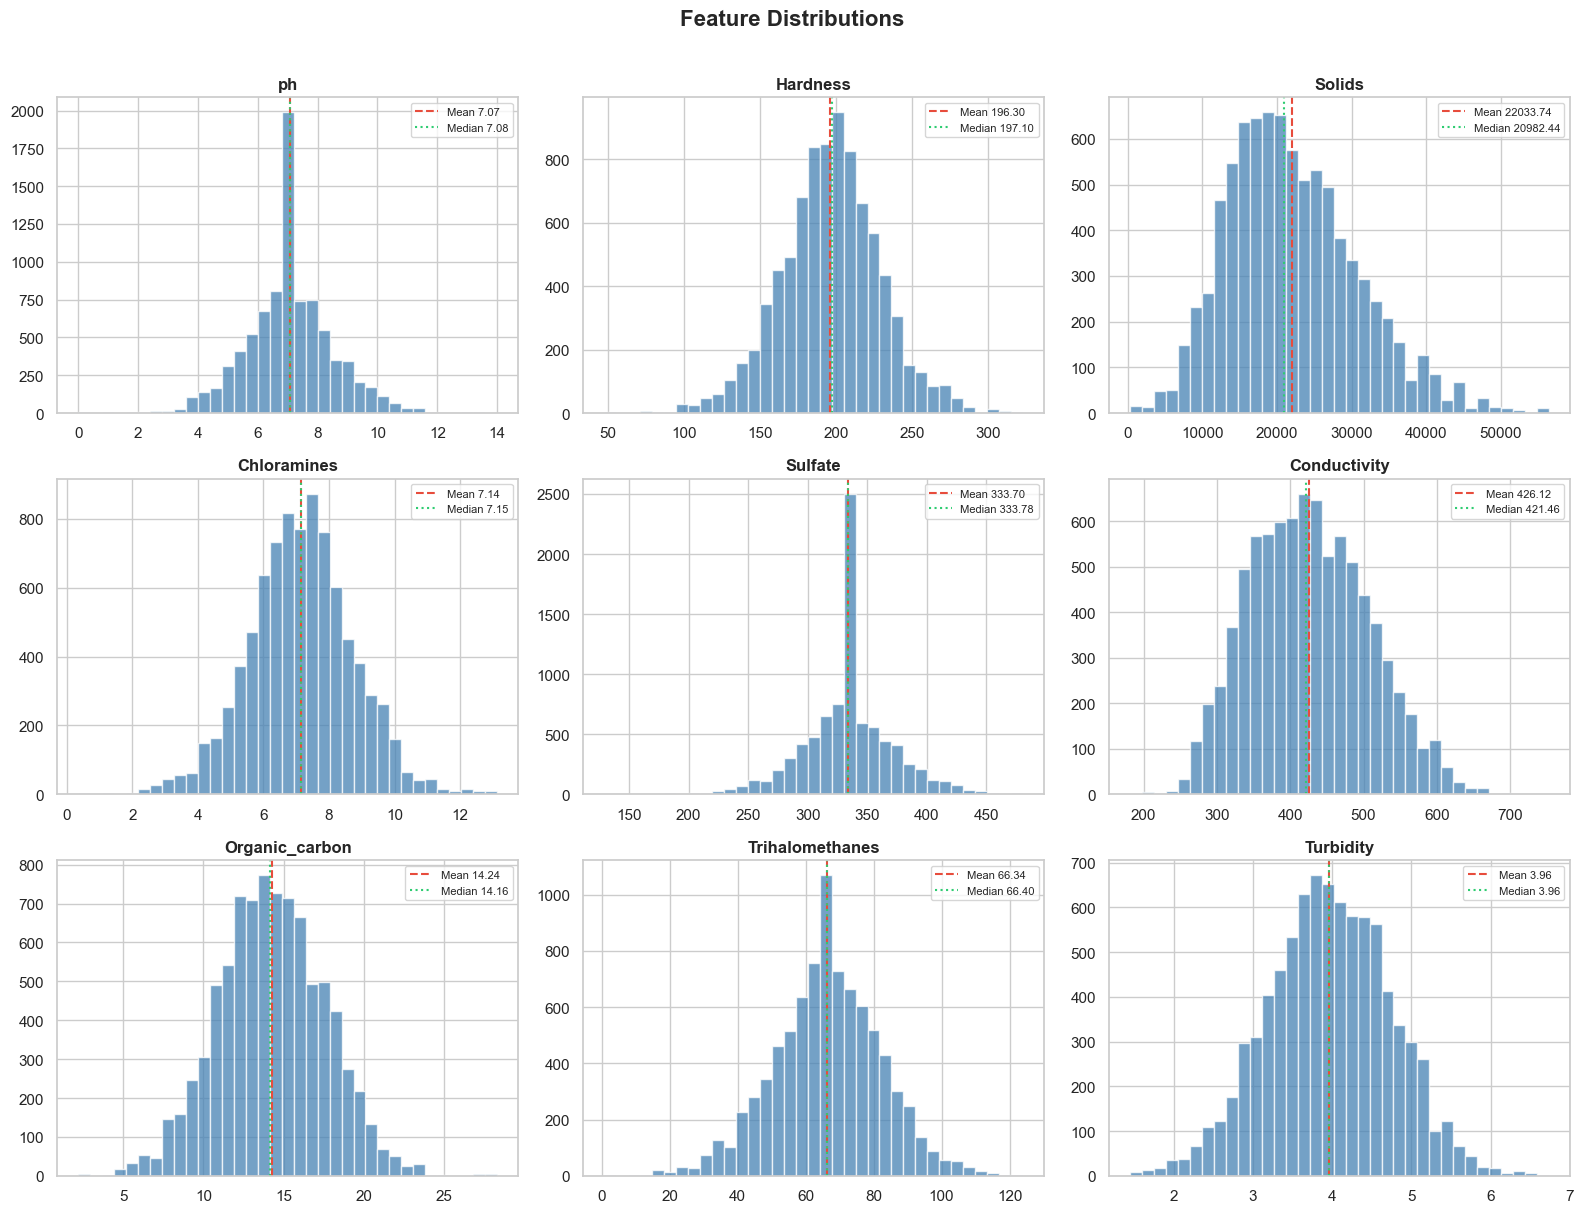

In [10]:
features = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate',
            'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

for i, feat in enumerate(features):
    ax = axes[i]
    ax.hist(df[feat], bins=35, alpha=0.75, color='steelblue', edgecolor='white')
    ax.axvline(df[feat].mean(),   color='#e74c3c', linestyle='--', lw=1.5,
               label=f'Mean {df[feat].mean():.2f}')
    ax.axvline(df[feat].median(), color='#2ecc71', linestyle=':',  lw=1.5,
               label=f'Median {df[feat].median():.2f}')
    ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Outlier Analysis (Box Plots)

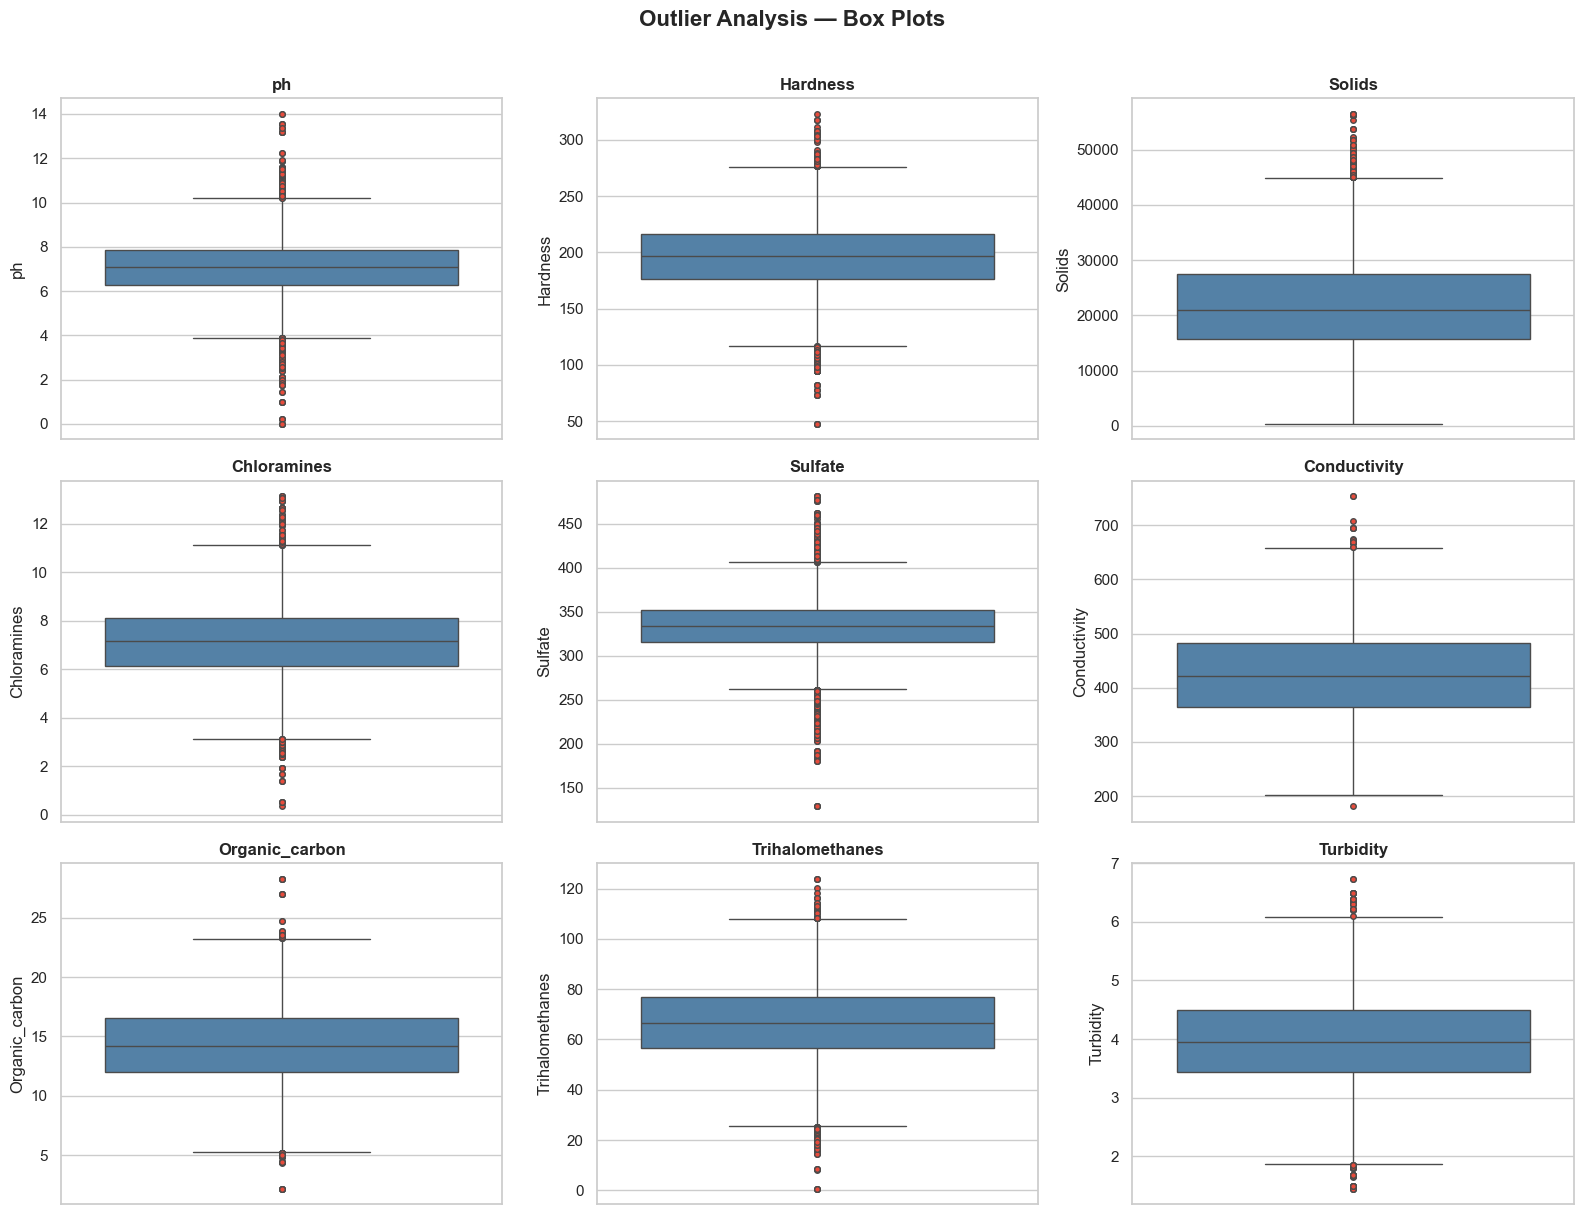

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

for i, feat in enumerate(features):
    sns.boxplot(y=df[feat], ax=axes[i], color='steelblue',
                flierprops={'marker': 'o', 'markerfacecolor': '#e74c3c', 'markersize': 4})
    axes[i].set_title(feat, fontweight='bold')

plt.suptitle('Outlier Analysis — Box Plots', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 8. Bivariate Analysis — Features vs Potability

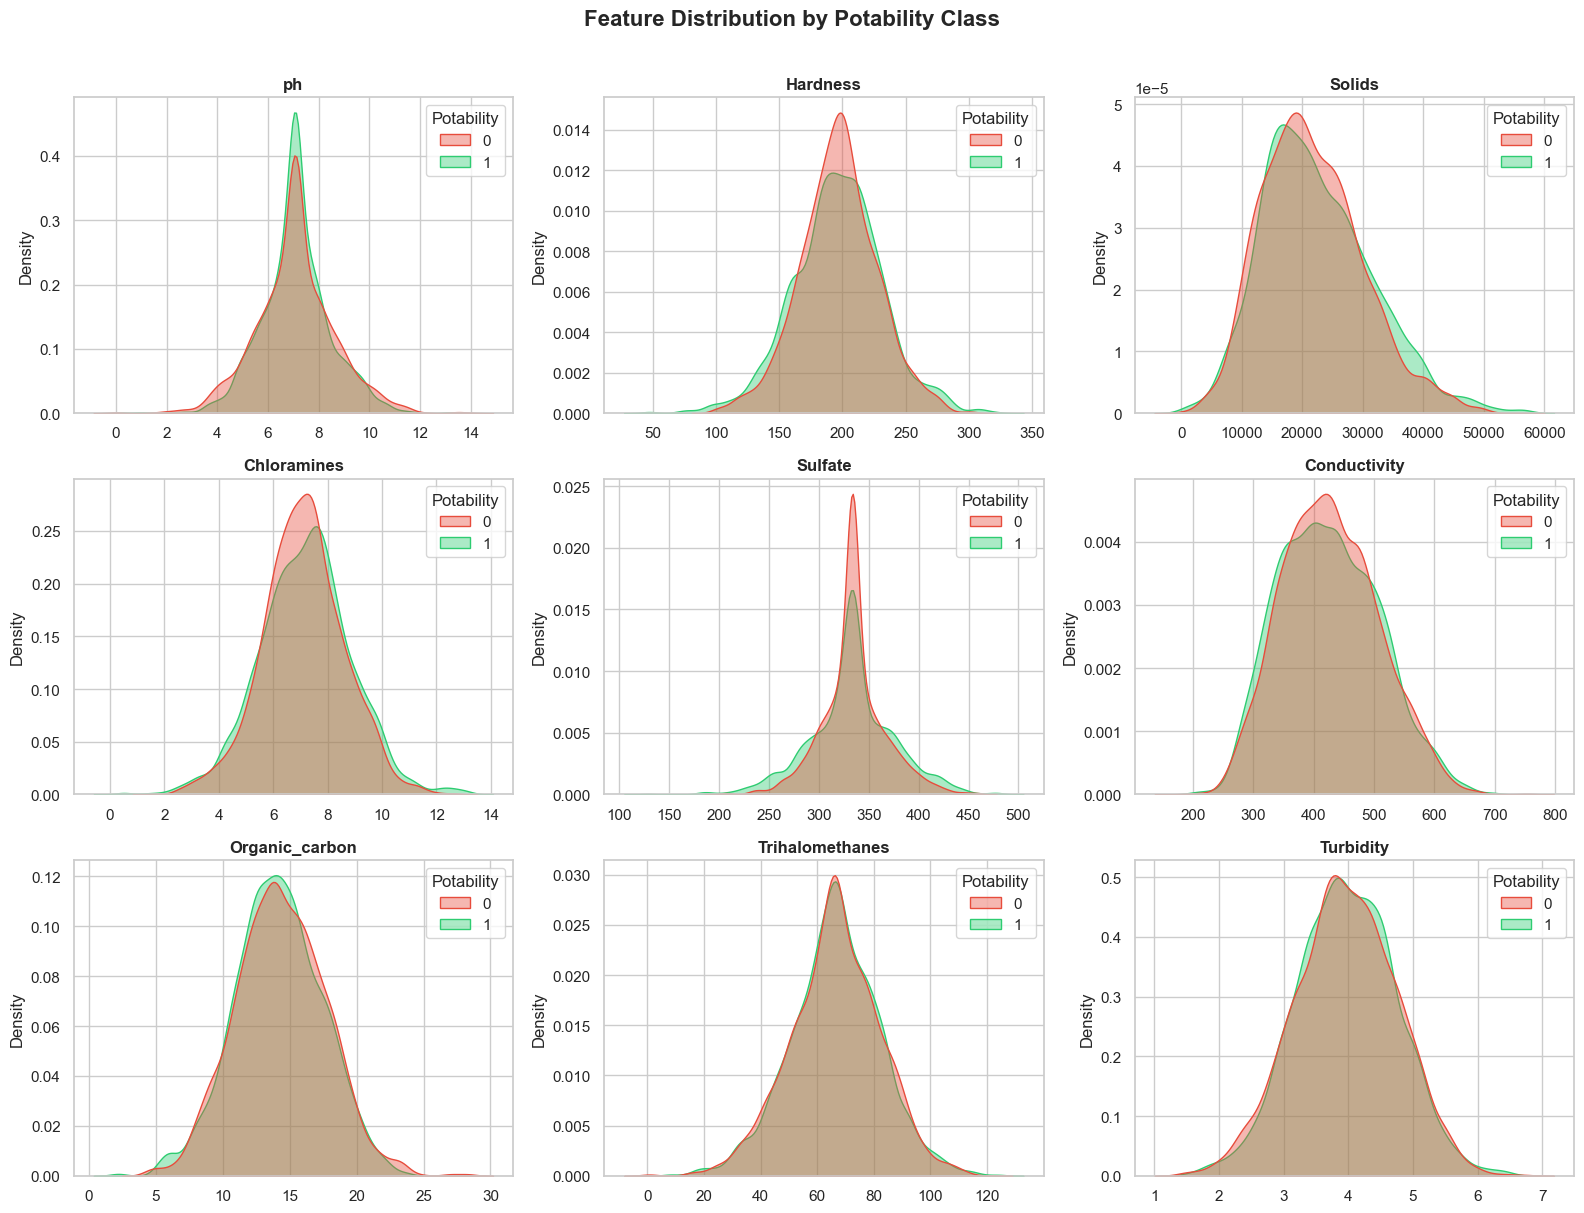

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()
palette = {0: '#e74c3c', 1: '#2ecc71'}

for i, feat in enumerate(features):
    sns.kdeplot(data=df, x=feat, hue='Potability', ax=axes[i],
                palette=palette, fill=True, alpha=0.4, common_norm=False)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Feature Distribution by Potability Class', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 9. Correlation Heatmap

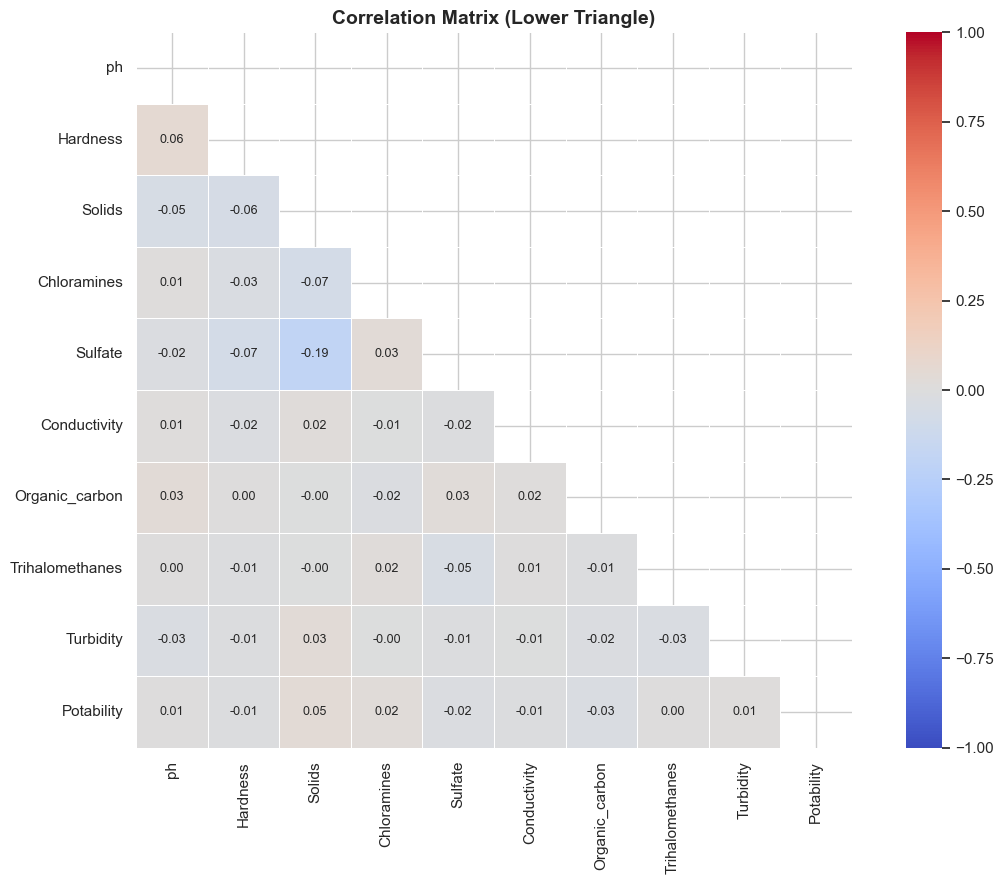


Feature correlation with Potability (absolute):
Solids             0.046706
Organic_carbon     0.029736
Chloramines        0.023516
Sulfate            0.018004
Conductivity       0.012237
Hardness           0.009918
Turbidity          0.008477
ph                 0.006419
Trihalomethanes    0.004517


In [13]:
corr = df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, square=True,
            annot_kws={'size': 9})
plt.title('Correlation Matrix (Lower Triangle)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with target
target_corr = corr['Potability'].drop('Potability').abs().sort_values(ascending=False)
print('\nFeature correlation with Potability (absolute):')
print(target_corr.to_string())

## 10. Feature Engineering

In [14]:
# Domain-inspired interaction features
df['Solids_Conductivity']  = df['Solids']    * df['Conductivity']
df['Chloramines_THMs']     = df['Chloramines'] * df['Trihalomethanes']
df['Hardness_Sulfate']     = df['Hardness']  * df['Sulfate']
df['Turbidity_Organic']    = df['Turbidity'] * df['Organic_carbon']

# Log transform for right-skewed features
df['log_Solids']           = np.log1p(df['Solids'])
df['log_Conductivity']     = np.log1p(df['Conductivity'])

# pH squared (non-linear relationship with potability)
df['ph_squared']           = df['ph'] ** 2

print(f'Shape after feature engineering: {df.shape}')
print('New columns:', [c for c in df.columns if c not in
      ['ph','Hardness','Solids','Chloramines','Sulfate','Conductivity',
       'Organic_carbon','Trihalomethanes','Turbidity','Potability']])

Shape after feature engineering: (8580, 17)
New columns: ['Solids_Conductivity', 'Chloramines_THMs', 'Hardness_Sulfate', 'Turbidity_Organic', 'log_Solids', 'log_Conductivity', 'ph_squared']


## 11. Train / Test Split & Scaling

In [15]:
X = df.drop('Potability', axis=1)
y = df['Potability']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train size : {X_train.shape[0]} samples')
print(f'Test  size : {X_test.shape[0]}  samples')
print(f'Features   : {X_train.shape[1]}')

Train size : 6864 samples
Test  size : 1716  samples
Features   : 16


In [16]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)

print('Scaling complete ✅')
X_train_scaled.describe().T[['mean','std']].head()

Scaling complete ✅


,mean,std
ph,6.252445e-16,1.000073
Hardness,4.492651e-16,1.000073
Solids,-9.316557e-17,1.000073
Chloramines,1.221504e-16,1.000073
Sulfate,1.586920e-15,1.000073


## 12. Save Artefacts for Modelling Notebook

In [17]:
# Save split data
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv',  index=False)
X_train_scaled.to_csv('X_train_scaled.csv', index=False)
X_test_scaled.to_csv('X_test_scaled.csv',   index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv',   index=False)

# Save scaler
joblib.dump(scaler, 'scaler.pkl')

print('✅ Artefacts saved:')
for f in ['X_train.csv','X_test.csv','X_train_scaled.csv',
           'X_test_scaled.csv','y_train.csv','y_test.csv','scaler.pkl']:
    print(f'   • {f}')

print('\n🚀 Ready for Notebook 2 — Modelling!')

✅ Artefacts saved:
   • X_train.csv
   • X_test.csv
   • X_train_scaled.csv
   • X_test_scaled.csv
   • y_train.csv
   • y_test.csv
   • scaler.pkl

🚀 Ready for Notebook 2 — Modelling!
